# Classification Metrics

### Objective

This notebook explores common classification metrics using the Wisconsin Diagnostic Breast Cancer (WDBC) dataset, as previously explored on 02_logistic_regression.

### Research Question

How well does a logistic regression model distinguish between benign and malignant tumors?

### Learning Objectives

- Understand the confusion matrix
- Calculate accuracy, precision, recall, specificity, and F1 score
- Understand the ROC curve and AUC
- Understand why different metrics may be appropriate for different classification problems

## 01. Why Classification Metrics

A classification model does not simply need to produce predictions. We also need to evaluate how well these predictions match the actual outcomes.

Different metrics measure different aspects of model performance. This is particularly important in healthcare, where false positives and false negatives may have different consequences, patient treatments, and patient outcomes.

### 1.1 Set Up and Load Dataset

In [ ]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Modules Imported")

#Load WDBC dataset, remove unnecessary columns, map diagnosis to binary 1/0.
df = pd.read_csv('/Users/hweeenheah/Downloads/EDA_Resources/machine-learning-foundations/02_Logistic Regression/wdbc.csv')
df = df.drop(columns=['id', 'Unnamed: 32'])
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
df.head(5)


Modules Imported


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 1.2 Set Up Logistic Regression Model

In [ ]:
#import modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

#set variables
X = df[['radius_mean']]
y = df['diagnosis']

#Train logistic regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained")

#y_pred is predicted class (0/1), use for confusion matrix, accuracy, precision, recall, specificity, F1. 
#Threshold 0.5.
y_pred = model.predict(X_test)
print(f"Predicted classes: {y_pred[:10]}")

#y_prob is predicted probability of malignancy (0-1), use for ROC and AUC
y_prob = model.predict_proba(X_test)[:, 1]
print(f"Predicted probabilities: {y_prob[:10]}")

#Put into table for easy comparison
table = pd.DataFrame({'Predicted Class': y_pred[:10], 'Predicted Probability': y_prob[:10]})
print(table)

Model trained
Predicted classes: [0 0 0 0 0 0 1 0 1 0]
Predicted probabilities: [4.32219400e-01 6.31060951e-02 9.87518621e-04 2.41470561e-02
 1.17084124e-01 8.14460753e-02 9.95423094e-01 2.25795398e-02
 8.04683554e-01 4.51662622e-02]
   Predicted Class  Predicted Probability
0                0               0.432219
1                0               0.063106
2                0               0.000988
3                0               0.024147
4                0               0.117084
5                0               0.081446
6                1               0.995423
7                0               0.022580
8                1               0.804684
9                0               0.045166


## 02. Confusion Matrix

A confusion matrix compares the model's predicted classifications to actual outcomes. 

The four possible outcomes are:
- **True Positive (TP):** Predicted malignant, actually malignant
- **True Negative (TN):** Predicted benign, actually benign
- **False Positive (FP):** Predicted malignant, actually benign
- **False Negative (FN):** Predicted benign, actually malignant

[[99  8]
 [16 48]]


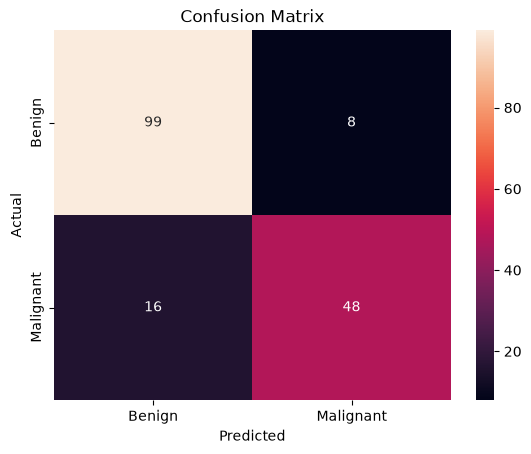

In [ ]:
#import module
from sklearn.metrics import confusion_matrix

#generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

#visualise confusion matrix
sns.heatmap(cm, annot=True, xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 2.1 Interpreting the Confusion Matrix

The model correctly classified:
- 99 benign tumours as benign (**True Negative**)
- 48 malignant tumours as malignant (**True Positive**)

The model incorrectly classified:
- 8 benign tumours as malignant (**False Positive**)
- 16 malignant tumours as benign (**False Negative**)

The confusion matrix allows us to see not just how many predictions were correct, but also the types of errors made by the classifier.

## 03. Accuracy, Precision, Recall, and F1

Different classification metrics provide different ways of evaluating model performance.

### 3.1 Accuracy

Accuracy measures the proportion of all predictions that were correctly classified. It provides a general estimate of how well the model performed overall. 

Accuracy = (TP + TN) / (TP + TN + FP + FN)

In [22]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.860


The model correctly classified 86% of the test samples. However, accuracy does not tell us what types of errors the model made. In healthcare settings, this can be important because false positive and false negatives may have different consequences. Therefore, additional metrics is needed to understand the model's performance in greater detail.

### 3.2 Precision

Precision measures how often a model is correct when it predicts the positive class. In this dataset, precision answers "Of all the tumours predicted to be malignant (positive), how many were actually malignant?"

Precision = TP / (TP + FP)

In [23]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.3f}")

Precision: 0.857


The model has a precision of 85.7%, which means that when the model predicts a tumour as malignant, it is correct 85.7% of the time. A higher precision means fewer false positive (FP) predictions.

### 3.3 Recall/Sensitivity

Recall measures the proportion of actual positive cases that were correctly identified by the model. In this dataset, recall answers "Of all the tumours that were actually malignant (positive), how many did the model correctly identify?"

Recall = TP / (TP + FN)

In [24]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.3f}")

Recall: 0.750


The model has a recall of 75.0%, which means that the mdoel correctly identified 75% of the malignant tumours in the test set. The remaining 25% were false negatives -- malignant tumours that the model incorrectly identified as benign. In healthcare, recall can be particularly important when missing a positive (malignant) case has serious consequences, like missing the optimal window of therapeutic intervention.

### 3.4 F1 Score

Precision focuses on avoiding false positives (FP) while recall focuses on avoiding false negatives (FN).
F1 score combines precision and recall into a single metric that balances the two. It is useful when we want to consider both false positives and false negatives rather than only focusing on one type of error. 

F1 = (2 x Precision x Recall) / (Precision + Recall)
   = (2TP) / (2TP + FP + FN)

In [25]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.3f}")

F1 Score: 0.800


The mdoel has an F1 score of approximately 0.800. The F1 score provides a balance between precision and recall. A high F1 score requires both precision and recall to be relatively higher. Hence, F1 can be useful when both false positives and false negatives are important.

### 3.5 Summary

| Metric | Model Score | What it tells us |
|---|---|---|
| **Accuracy** | 86.0% | How often the model is correct overall |
| **Precision** | 85.7% | How reliable positive predictions are |
| **Recall** | 75.0% | How many actual positive cases are identified |
| **F1 Score** | 80.0% | Balance between precision and recall |


## 04. Specificity

## 05. ROC Graph and AUC

## 06. Choosing the Right Metric

## 07. Key takeaways